# TUBES DAI Fraud Detection

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")
sample = pd.read_csv("sample_submission.csv")


In [3]:
train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,M,UK,mobile,Android,clothing,17.70,...,0.793,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,F,IN,mobile,Android,restaurants,NaN,...,NaN,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,M,US,desktop,iOS,restaurants,5.20,...,0.281,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,F,US,mobile,Android,electronics,180.70,...,0.061,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,M,UK,mobile,Android,gas,35.45,...,0.592,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,M,IN,mobile,Android,electronics,7.67,...,0.888,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,F,UK,mobile,Android,restaurants,47.95,...,0.306,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,F,US,mobile,Android,services,44.29,...,0.735,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,M,IN,mobile,Windows,electronics,NaN,...,NaN,906,0,1,2,0.30,0.10,67.30,0,0


In [4]:
train.isna().sum() 

ID                           0
transaction_id               0
user_id                      0
age                          0
gender                       0
country                      0
device_type                  0
device_os                    0
merchant_category            0
transaction_amount        2419
transaction_type             0
time_of_day                  0
day_of_week                  0
transaction_duration         0
num_prev_transactions        0
avg_transaction_amount    2419
std_transaction_amount       0
transactions_last_24h        0
transactions_last_1h         0
failed_login_attempts        0
ip_risk_score                0
device_trust_score        2419
account_age_days             0
has_chargeback_history       0
shared_ip_users              0
shared_device_users          0
merchant_risk                0
country_risk                 0
distance_from_home           0
is_new_country               0
is_fraud                     0
dtype: int64

In [5]:
new_train = train.copy()

In [6]:
new_train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,M,UK,mobile,Android,clothing,17.70,...,0.793,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,F,IN,mobile,Android,restaurants,NaN,...,NaN,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,M,US,desktop,iOS,restaurants,5.20,...,0.281,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,F,US,mobile,Android,electronics,180.70,...,0.061,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,M,UK,mobile,Android,gas,35.45,...,0.592,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,M,IN,mobile,Android,electronics,7.67,...,0.888,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,F,UK,mobile,Android,restaurants,47.95,...,0.306,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,F,US,mobile,Android,services,44.29,...,0.735,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,M,IN,mobile,Windows,electronics,NaN,...,NaN,906,0,1,2,0.30,0.10,67.30,0,0


# 1. Data Description

menjelaskan identitas data yang mewakili analaisis pola, pengenalan anomali, dsb.  Terdiri atas:
* memahami struktur data
* memeriksa nilai-nilai tingkasan statistik

## 1.1 Memahami struktur data
* Informasi Atributes
* Tipe Data per Atributes
* Jumlah baris dan kolom

In [7]:
# Informasi atributes 
# Notes: dibuat dalam tabel (dataframes) untuk mempermudah visualisasi

info_list = []


for column, dtype in new_train.dtypes.items():
    min_range = "-"
    max_range = "-"
    if dtype.name == 'int64':
        jenis_data = "Integer"
        min_range = new_train[column].min()
        max_range = new_train[column].max()
    elif dtype.name == 'float64':
        jenis_data = "Real"
        min_range = new_train[column].min()
        max_range = new_train[column].max()
    else:
        jenis_data = "Kategorikal"

    info_dict = {
        "Nama Atributtes" : column,
        "Jenis_Data": jenis_data,
        "Missing Values": new_train[column].isna().sum(),
        "Min Range": min_range,
        "Max Range": max_range
    }
    info_list.append(info_dict)

df_info = pd.DataFrame(info_list)
df_info

,Nama Atributtes,Jenis_Data,Missing Values,Min Range,Max Range
0,ID,Integer,0,0,99999
1,transaction_id,Kategorikal,0,-,-
2,user_id,Integer,0,1,29999
3,age,Integer,0,18,79
4,gender,Kategorikal,0,-,-
5,country,Kategorikal,0,-,-
6,device_type,Kategorikal,0,-,-
7,device_os,Kategorikal,0,-,-
8,merchant_category,Kategorikal,0,-,-
9,transaction_amount,Real,2419,0.01,20601.13335


In [8]:
# Untuk mengetahui jumlah baris dan kolom

print("="*100)
print(f"Jumlah Baris:    {new_train.shape[0]}")
print(f"Jumlah Kolom:    {new_train.shape[1]}")
print("="*100)

Jumlah Baris:    100000
Jumlah Kolom:    31


## 2. Mengetahui Nilai-Nilai Ringkasan Statistik

In [9]:
print(new_train.describe())

                  ID        user_id            age  transaction_amount  \
count  100000.000000  100000.000000  100000.000000        97581.000000   
mean    49999.500000   15040.173180      48.484150          126.855288   
std     28867.657797    8655.074007      17.892168          376.035544   
min         0.000000       1.000000      18.000000            0.010000   
25%     24999.750000    7549.000000      33.000000           26.910000   
50%     49999.500000   15093.000000      48.000000           64.460000   
75%     74999.250000   22541.000000      64.000000          131.060000   
max     99999.000000   29999.000000      79.000000        20601.133350   

         time_of_day    day_of_week  transaction_duration  \
count  100000.000000  100000.000000         100000.000000   
mean       12.770160       2.780700              3.999587   
std         5.748626       2.064754              4.012831   
min         0.000000       0.000000              0.000000   
25%         8.000000       1

In [10]:
# Lihat hanya kolom yang ada NaN nya
print("="*100)
print("Kolom yang mengandung NaN:")
nan_columns = new_train.columns[new_train.isna().any()].tolist()
print(new_train[nan_columns].isna().sum())
print("="*100)

print("Mean\n")
print(new_train[nan_columns].mean())
print("="*100)
print("StdDev\n")
print(new_train[nan_columns].std())
print("="*100)
print("Median\n")
print(new_train[nan_columns].quantile(0.5))

Kolom yang mengandung NaN:
transaction_amount        2419
avg_transaction_amount    2419
device_trust_score        2419
dtype: int64
Mean

transaction_amount        126.855288
avg_transaction_amount     69.969722
device_trust_score          0.499480
dtype: float64
StdDev

transaction_amount        376.035544
avg_transaction_amount     29.961530
device_trust_score          0.288812
dtype: float64
Median

transaction_amount        64.460
avg_transaction_amount    69.990
device_trust_score         0.499
Name: 0.5, dtype: float64


<Axes: >

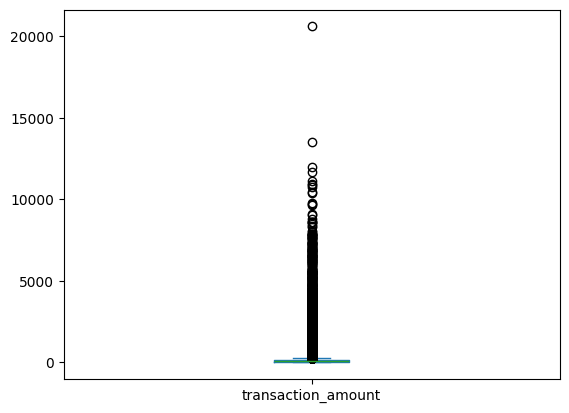

In [11]:
# Outlier
new_train["transaction_amount"].plot(kind="box")


In [12]:
trans_median = new_train['transaction_amount'].median()
new_train['transaction_amount'] = new_train['transaction_amount'].fillna(trans_median)


In [13]:
columns = ["transaction_amount"]
for column in columns:
    column_data = new_train[column]

    q1 = np.percentile(column_data, 25)
    q3 = np.percentile(column_data, 75)
    IQR = q3 - q1

    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR

    outliers = column_data[(column_data < lower) | (column_data > upper)]
    median = column_data.median()
    column_data[(column_data < lower) | (column_data > upper)] = median

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18520\1974441144.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  column_data[(column_data < lower) | (column_data > upper)] = median


In [14]:
avg_trans_mean = new_train['avg_transaction_amount'].mean()
new_train['avg_transaction_amount'] = new_train['avg_transaction_amount'].fillna(avg_trans_mean)



In [15]:
columns = ["avg_transaction_amount"]
for column in columns:
    column_data = new_train[column]

    q1 = np.percentile(column_data, 25)
    q3 = np.percentile(column_data, 75)
    IQR = q3 - q1

    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR

    outliers = column_data[(column_data < lower) | (column_data > upper)]
    mean = column_data.mean()
    column_data[(column_data < lower) | (column_data > upper)] = mean

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18520\2092887278.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  column_data[(column_data < lower) | (column_data > upper)] = mean


In [16]:
device_trust_mean = new_train['device_trust_score'].mean()
new_train['device_trust_score'] = new_train['device_trust_score'].fillna(device_trust_mean)



In [17]:
columns = ["device_trust_score"]
for column in columns:
    column_data = new_train[column]

    q1 = np.percentile(column_data, 25)
    q3 = np.percentile(column_data, 75)
    IQR = q3 - q1

    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR

    outliers = column_data[(column_data < lower) | (column_data > upper)]
    mean = column_data.mean()
    column_data[(column_data < lower) | (column_data > upper)] = mean

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18520\185162119.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  column_data[(column_data < lower) | (column_data > upper)] = mean


## Data Transformation

In [18]:
new_train.isna().sum()

ID                        0
transaction_id            0
user_id                   0
age                       0
gender                    0
country                   0
device_type               0
device_os                 0
merchant_category         0
transaction_amount        0
transaction_type          0
time_of_day               0
day_of_week               0
transaction_duration      0
num_prev_transactions     0
avg_transaction_amount    0
std_transaction_amount    0
transactions_last_24h     0
transactions_last_1h      0
failed_login_attempts     0
ip_risk_score             0
device_trust_score        0
account_age_days          0
has_chargeback_history    0
shared_ip_users           0
shared_device_users       0
merchant_risk             0
country_risk              0
distance_from_home        0
is_new_country            0
is_fraud                  0
dtype: int64

In [19]:
compare_gender = pd.DataFrame(new_train["gender"], new_train["is_fraud"])
compare_gender

,gender
is_fraud,
1,F
1,F
0,M
0,M
0,M
...,...
0,M
1,F
0,M


In [20]:
compare_gender = pd.DataFrame({
    "gender": ["F", "M"]
})

compare_gender

,gender
0,F
1,M


In [21]:
fraud_per_gender = new_train.groupby('gender')['is_fraud'].sum().reset_index()
fraud_per_gender.rename(columns={'is_fraud': 'total_fraud_cases'}, inplace=True)


In [22]:
compare_gender["n_gender_fraud"] = fraud_per_gender["total_fraud_cases"]

In [23]:
compare_gender

,gender,n_gender_fraud
0,F,5801
1,M,8327


In [24]:
transfromed_new_train = new_train.copy()

In [25]:
gender_mapping = {'M': 1, 'F': 0}
transfromed_new_train['gender'] = transfromed_new_train['gender'].map(gender_mapping)

In [26]:
transfromed_new_train["country"].value_counts()

country
US    29731
IN    29375
ID    12064
CA    11221
UK    10835
BR     2601
FR     1766
DE     1462
SG      495
AU      450
Name: count, dtype: int64

In [27]:
fraud_per_country = new_train.groupby('country')['is_fraud'].sum().reset_index()
fraud_per_country.rename(columns={'is_fraud': 'total_fraud_cases'}, inplace=True)
fraud_per_country["total_per_country"] = transfromed_new_train["country"].value_counts()
fraud_per_country["fraud_rate"] = fraud_per_country['total_fraud_cases'] / fraud_per_country['total_per_country']
fraud_per_country

,country,total_fraud_cases,total_per_country,fraud_rate
0,AU,50,NaN,NaN
1,BR,387,NaN,NaN
2,CA,1569,NaN,NaN
3,DE,209,NaN,NaN
4,FR,232,NaN,NaN
5,ID,1694,NaN,NaN
6,IN,4146,NaN,NaN
7,SG,57,NaN,NaN
8,UK,1575,NaN,NaN
9,US,4209,NaN,NaN


In [28]:
fraud_per_country = fraud_per_country.sort_values(by='fraud_rate', ascending=False).reset_index()
fraud_per_country

,index,country,total_fraud_cases,total_per_country,fraud_rate
0,0,AU,50,NaN,NaN
1,1,BR,387,NaN,NaN
2,2,CA,1569,NaN,NaN
3,3,DE,209,NaN,NaN
4,4,FR,232,NaN,NaN
5,5,ID,1694,NaN,NaN
6,6,IN,4146,NaN,NaN
7,7,SG,57,NaN,NaN
8,8,UK,1575,NaN,NaN
9,9,US,4209,NaN,NaN


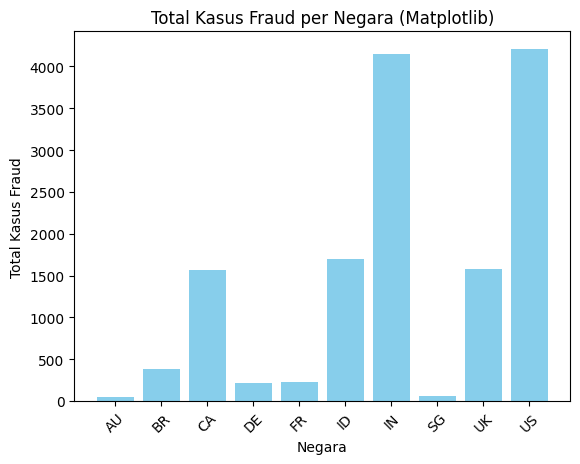

In [29]:
plt.bar(
    fraud_per_country['country'], 
    fraud_per_country['total_fraud_cases'], 
    color='skyblue'
)

plt.title('Total Kasus Fraud per Negara (Matplotlib)')
plt.xlabel('Negara')
plt.ylabel('Total Kasus Fraud')
plt.xticks(rotation=45)
plt.show()

In [30]:
country_mapping = {"US": 9, "IN": 8, "ID": 7, "UK": 6, "CA": 5, "BR": 4, "FR": 3, "DE": 2, "SG": 1, "AU": 0}
transfromed_new_train['country'] = transfromed_new_train['country'].map(country_mapping)
transfromed_new_train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,1,6,mobile,Android,clothing,17.70,...,0.79300,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,0,8,mobile,Android,restaurants,64.46,...,0.49948,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,1,9,desktop,iOS,restaurants,5.20,...,0.28100,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,0,9,mobile,Android,electronics,180.70,...,0.06100,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,1,6,mobile,Android,gas,35.45,...,0.59200,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,1,8,mobile,Android,electronics,7.67,...,0.88800,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,0,6,mobile,Android,restaurants,47.95,...,0.30600,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,0,9,mobile,Android,services,44.29,...,0.73500,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,1,8,mobile,Windows,electronics,64.46,...,0.49948,906,0,1,2,0.30,0.10,67.30,0,0


In [31]:
transfromed_new_train["device_type"].value_counts()

device_type
mobile     78292
desktop    18163
tablet      3545
Name: count, dtype: int64

In [32]:
fraud_per_device_type = new_train.groupby('device_type')['is_fraud'].sum().reset_index()
fraud_per_device_type.rename(columns={'is_fraud': 'total_fraud_cases'}, inplace=True)
fraud_per_device_type

,device_type,total_fraud_cases
0,desktop,1962
1,mobile,11791
2,tablet,375


In [33]:
fraud_per_device_type = fraud_per_device_type.sort_values(by='total_fraud_cases', ascending=False).reset_index()
fraud_per_device_type

,index,device_type,total_fraud_cases
0,1,mobile,11791
1,0,desktop,1962
2,2,tablet,375


In [34]:
device_type_mapping = {"mobile": 2, "desktop": 1, "tablet": 0}
transfromed_new_train['device_type'] = transfromed_new_train['device_type'].map(device_type_mapping)
transfromed_new_train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,1,6,2,Android,clothing,17.70,...,0.79300,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,0,8,2,Android,restaurants,64.46,...,0.49948,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,1,9,1,iOS,restaurants,5.20,...,0.28100,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,0,9,2,Android,electronics,180.70,...,0.06100,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,1,6,2,Android,gas,35.45,...,0.59200,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,1,8,2,Android,electronics,7.67,...,0.88800,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,0,6,2,Android,restaurants,47.95,...,0.30600,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,0,9,2,Android,services,44.29,...,0.73500,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,1,8,2,Windows,electronics,64.46,...,0.49948,906,0,1,2,0.30,0.10,67.30,0,0


In [35]:
transfromed_new_train["device_os"].value_counts()

device_os
Android    49183
iOS        21990
Windows    20750
Linux       6314
MacOS       1763
Name: count, dtype: int64

In [36]:
fraud_per_device_os = new_train.groupby('device_os')['is_fraud'].sum().reset_index()
fraud_per_device_os.rename(columns={'is_fraud': 'total_fraud_cases'}, inplace=True)
fraud_per_device_os

,device_os,total_fraud_cases
0,Android,6936
1,Linux,883
2,MacOS,250
3,Windows,2948
4,iOS,3111


In [37]:
fraud_per_device_os = fraud_per_device_os.sort_values(by='total_fraud_cases', ascending=False).reset_index()
fraud_per_device_os

,index,device_os,total_fraud_cases
0,0,Android,6936
1,4,iOS,3111
2,3,Windows,2948
3,1,Linux,883
4,2,MacOS,250


In [38]:
device_os_mapping = {"Android": 4, "iOS": 3, "Windows": 2, "Linux": 1, "MacOS": 0}
transfromed_new_train['device_os'] = transfromed_new_train['device_os'].map(device_os_mapping)
transfromed_new_train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,1,6,2,4,clothing,17.70,...,0.79300,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,0,8,2,4,restaurants,64.46,...,0.49948,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,1,9,1,3,restaurants,5.20,...,0.28100,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,0,9,2,4,electronics,180.70,...,0.06100,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,1,6,2,4,gas,35.45,...,0.59200,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,1,8,2,4,electronics,7.67,...,0.88800,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,0,6,2,4,restaurants,47.95,...,0.30600,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,0,9,2,4,services,44.29,...,0.73500,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,1,8,2,2,electronics,64.46,...,0.49948,906,0,1,2,0.30,0.10,67.30,0,0


In [39]:
transfromed_new_train['merchant_category'].value_counts()

merchant_category
electronics    27973
restaurants    25155
gas            13160
groceries       9662
travel          8696
clothing        5179
services        4662
financial       4404
luxury          1109
Name: count, dtype: int64

In [40]:
fraud_per_merchant_category = new_train.groupby('merchant_category')['is_fraud'].sum().reset_index()
fraud_per_merchant_category.rename(columns={'is_fraud': 'total_fraud_cases'}, inplace=True)
fraud_per_merchant_category

,merchant_category,total_fraud_cases
0,clothing,749
1,electronics,4035
2,financial,714
3,gas,1751
4,groceries,1301
5,luxury,180
6,restaurants,3489
7,services,616
8,travel,1293


In [41]:
fraud_per_merchant_category = fraud_per_merchant_category.sort_values(by='total_fraud_cases', ascending=False).reset_index()
fraud_per_merchant_category

,index,merchant_category,total_fraud_cases
0,1,electronics,4035
1,6,restaurants,3489
2,3,gas,1751
3,4,groceries,1301
4,8,travel,1293
5,0,clothing,749
6,2,financial,714
7,7,services,616
8,5,luxury,180


In [42]:
merchant_category_mapping = {"electronics": 8, "restaurants": 7, "gas": 6, "groceries": 5, "travel": 4, "clothing": 3, "financial": 2, "services": 1, "luxury": 0}
transfromed_new_train['merchant_category'] = transfromed_new_train['merchant_category'].map(merchant_category_mapping)
transfromed_new_train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,1,6,2,4,3,17.70,...,0.79300,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,0,8,2,4,7,64.46,...,0.49948,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,1,9,1,3,7,5.20,...,0.28100,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,0,9,2,4,8,180.70,...,0.06100,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,1,6,2,4,6,35.45,...,0.59200,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,1,8,2,4,8,7.67,...,0.88800,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,0,6,2,4,7,47.95,...,0.30600,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,0,9,2,4,1,44.29,...,0.73500,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,1,8,2,2,8,64.46,...,0.49948,906,0,1,2,0.30,0.10,67.30,0,0


In [43]:
transfromed_new_train['transaction_type'].value_counts()

transaction_type
purchase      59395
withdrawal    16551
topup         14178
transfer       9876
Name: count, dtype: int64

In [44]:
fraud_per_transaction_type = new_train.groupby('transaction_type')['is_fraud'].sum().reset_index()
fraud_per_transaction_type.rename(columns={'is_fraud': 'total_fraud_cases'}, inplace=True)
fraud_per_transaction_type

,transaction_type,total_fraud_cases
0,purchase,8524
1,topup,2005
2,transfer,1333
3,withdrawal,2266


In [45]:
fraud_per_transaction_type = fraud_per_transaction_type.sort_values(by='total_fraud_cases', ascending=False).reset_index()
fraud_per_transaction_type

,index,transaction_type,total_fraud_cases
0,0,purchase,8524
1,3,withdrawal,2266
2,1,topup,2005
3,2,transfer,1333


In [46]:
transaction_type_mapping = {"purchase": 3, "withdrawal": 2, "topup": 1, "transfer": 0}
transfromed_new_train['transaction_type'] = transfromed_new_train['transaction_type'].map(transaction_type_mapping)
transfromed_new_train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,1,6,2,4,3,17.70,...,0.79300,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,0,8,2,4,7,64.46,...,0.49948,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,1,9,1,3,7,5.20,...,0.28100,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,0,9,2,4,8,180.70,...,0.06100,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,1,6,2,4,6,35.45,...,0.59200,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,1,8,2,4,8,7.67,...,0.88800,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,0,6,2,4,7,47.95,...,0.30600,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,0,9,2,4,1,44.29,...,0.73500,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,1,8,2,2,8,64.46,...,0.49948,906,0,1,2,0.30,0.10,67.30,0,0


## Split Data

In [47]:
x = transfromed_new_train.copy()

In [48]:
x = x.drop(columns=["is_fraud"])

In [49]:
x = x.drop(columns=["ID", "transaction_id", "user_id", "age"])
x

,gender,country,device_type,device_os,merchant_category,transaction_amount,transaction_type,time_of_day,day_of_week,transaction_duration,...,ip_risk_score,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country
0,1,6,2,4,3,17.70,3,18,1,3.04,...,0.464,0.79300,1056,0,1,1,0.10,0.04,9.66,0
1,0,8,2,4,7,64.46,3,7,3,0.33,...,0.997,0.49948,1867,0,1,1,0.12,0.10,12.05,0
2,1,9,1,3,7,5.20,3,15,5,7.85,...,0.940,0.28100,1726,1,2,2,0.12,0.05,181.28,0
3,0,9,2,4,8,180.70,3,18,3,4.71,...,0.166,0.06100,30,1,1,1,0.30,0.05,33.26,0
4,1,6,2,4,6,35.45,3,8,3,1.56,...,0.870,0.59200,1386,0,3,1,0.05,0.04,174.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,8,2,4,8,7.67,3,13,0,4.74,...,0.411,0.88800,1593,0,0,0,0.30,0.10,321.83,0
99996,0,6,2,4,7,47.95,1,11,0,4.79,...,0.589,0.30600,673,0,6,2,0.12,0.04,48.53,0
99997,0,9,2,4,1,44.29,3,19,5,0.11,...,0.044,0.73500,1511,0,1,0,0.08,0.05,163.73,0
99998,1,8,2,2,8,64.46,3,6,0,2.29,...,0.936,0.49948,906,0,1,2,0.30,0.10,67.30,0


In [50]:
y = transfromed_new_train['is_fraud'].copy()
y = pd.DataFrame(y)
y

,is_fraud
0,1
1,1
2,0
3,0
4,0
...,...
99995,0
99996,1
99997,0
99998,0


## Training Data

In [51]:
from sklearn.model_selection import train_test_split
from logistic_regression import LogisticRegressionScratch
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 2. Data Shaping (Sudah Benar)
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

# 3. Inisialisasi Model CUSTOM ANDA
# Hapus parameter yang tidak dikenal oleh model custom Anda
# (solver, random_state, class_weight).
# Gunakan parameter yang dikenali model custom: learning_rate, n_iterations, regularization.

model_lr_scratch = LogisticRegressionScratch(
    learning_rate=0.01,   # Anda bisa coba 0.1 atau 0.001 jika tidak konvergen
    n_iterations=5000,    # Coba tingkatkan iterasi
    regularization='l2',  # Contoh: menggunakan L2 regularization
    lambda_=0.01,         # Nilai lambda untuk regularisasi
    verbose=True          # Untuk melihat cost saat training
)

# 4. Melatih Model
model_lr_scratch.fit(x_train, y_train)

# 5. Prediksi
y_pred = model_lr_scratch.predict(x_test)
y_prob = model_lr_scratch.predict_proba(x_test) # predict_proba() sudah mengembalikan 1D array

# 6. Evaluasi (Sudah Benar)
conf_matrix = confusion_matrix(y_test, y_pred)
print("--- Confusion Matrix ---")
print(conf_matrix)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_prob)
print(f"\nROC AUC Score: {auc_score:.4f}")

Iteration 0/5000 - Cost: 4.8795
Stopping early at iteration 10 because cost (29.6265) exceeded 28.
Training completed! Final cost: 29.6265
--- Confusion Matrix ---
[[    0 17174]
 [    0  2826]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     17174
           1       0.14      1.00      0.25      2826

    accuracy                           0.14     20000
   macro avg       0.07      0.50      0.12     20000
weighted avg       0.02      0.14      0.03     20000


ROC AUC Score: 0.4995


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [52]:

df_submission_ids = test['ID'].copy()


In [53]:
test_final = test.copy()
test_final['gender'] = test_final['gender'].map(gender_mapping)
test_final['country'] = test_final['country'].map(country_mapping)
test_final['device_type'] = test_final['device_type'].map(device_type_mapping)
test_final['device_os'] = test_final['device_os'].map(device_os_mapping)
test_final['merchant_category'] = test_final['merchant_category'].map(merchant_category_mapping)
test_final['transaction_type'] = test_final['transaction_type'].map(transaction_type_mapping)

In [54]:
# 1. Hapus kolom-kolom yang tidak digunakan (ID, text, dll.)
# Hapus kolom yang HARUS dihilangkan karena model tidak menggunakannya (sama persis dengan x_train)
# Berdasarkan error sebelumnya, kita harus menghapus 'transaction_id', 'user_id', dan 'age'.

x_submission = test_final.drop(
    columns=[
        'ID',              
        'transaction_id',  
        'user_id',         
        'age',             
        # Jika Anda menghapus kolom lain di data train, tambahkan di sini.
    ]
).copy()

# 2. Ambil Kolom ID untuk Submission
# Kita perlu ID transaksi asli (sebelum dihapus) untuk file submission
df_submission_ids = test_final[['ID']].copy()


# 3. Handle Missing Values (NaN)
# Jika Anda mengisi NaN di data train (misalnya dengan Median/Mean), 
# Anda harus mengisi NaN di x_submission dengan nilai Median/Mean yang SAMA dari data train.
# Jika Anda tidak memiliki nilai Median/Mean dari data train, gunakan median/mean dari x_submission untuk saat ini,
# tetapi ini kurang ideal.

# Jika ada NaN di x_submission, Anda akan mendapatkan error. 
# Cek dan imputasi (misal: isi dengan 0 atau median):
x_submission.fillna(0, inplace=True) # Contoh: Mengisi semua NaN dengan 0 (Sederhana)


# 4. Prediksi Final (Gunakan model terbaik Anda)
# Ganti 'model_lr' dengan nama variabel model yang sudah dilatih (misal: model_lr_balanced)
model_final = model_lr_scratch # Ganti jika nama variabel Anda berbeda

# Ambil probabilitas (yang diminta untuk metrik AUC)
final_probabilities = model_final.predict(x_submission)


# 5. Buat dan Simpan File Submission

df_submission = pd.DataFrame({
    'ID': df_submission_ids['ID'], 
    'is_fraud': final_probabilities 
})

df_submission.to_csv('submission.csv', index=False) 

print("==================================================")
print("Selamat! File submission_final.csv berhasil dibuat.")
print(f"Total {len(df_submission)} prediksi berhasil dicatat.")
print("==================================================")

Selamat! File submission_final.csv berhasil dibuat.
Total 100000 prediksi berhasil dicatat.


## Transforms 2

In [55]:
nipro_new_train = new_train.copy()

In [56]:
gender_mapping = {'M': 1, 'F': 0}
nipro_new_train['gender'] = nipro_new_train['gender'].map(gender_mapping)

In [57]:
nipro_new_train["country"].value_counts()

country
US    29731
IN    29375
ID    12064
CA    11221
UK    10835
BR     2601
FR     1766
DE     1462
SG      495
AU      450
Name: count, dtype: int64

In [58]:
f_p_con = nipro_new_train.groupby('country')['is_fraud'].sum().reset_index()
f_p_con.rename(columns={'is_fraud': 'total_fraud_cases'}, inplace=True)
country_pop_counts = nipro_new_train["country"].value_counts()
f_p_con['total_per_country'] = f_p_con['country'].map(country_pop_counts)
f_p_con['fraud_rate'] = f_p_con['total_fraud_cases'] / f_p_con['total_per_country']
f_p_con

,country,total_fraud_cases,total_per_country,fraud_rate
0,AU,50,450,0.111111
1,BR,387,2601,0.148789
2,CA,1569,11221,0.139827
3,DE,209,1462,0.142955
4,FR,232,1766,0.131370
5,ID,1694,12064,0.140418
6,IN,4146,29375,0.141140
7,SG,57,495,0.115152
8,UK,1575,10835,0.145362
9,US,4209,29731,0.141569


In [59]:
country_fraud_rate_mapping = f_p_con.set_index('country')['fraud_rate'].to_dict()
nipro_new_train['country'] = nipro_new_train['country'].map(country_fraud_rate_mapping)
nipro_new_train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,1,0.145362,mobile,Android,clothing,17.70,...,0.79300,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,0,0.141140,mobile,Android,restaurants,64.46,...,0.49948,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,1,0.141569,desktop,iOS,restaurants,5.20,...,0.28100,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,0,0.141569,mobile,Android,electronics,180.70,...,0.06100,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,1,0.145362,mobile,Android,gas,35.45,...,0.59200,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,1,0.141140,mobile,Android,electronics,7.67,...,0.88800,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,0,0.145362,mobile,Android,restaurants,47.95,...,0.30600,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,0,0.141569,mobile,Android,services,44.29,...,0.73500,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,1,0.141140,mobile,Windows,electronics,64.46,...,0.49948,906,0,1,2,0.30,0.10,67.30,0,0


In [60]:
f_p_device_type = nipro_new_train.groupby('device_type')['is_fraud'].sum().reset_index()
f_p_device_type.rename(columns={'is_fraud': 'total_fraud_cases'}, inplace=True)
device_type_pop_counts = nipro_new_train["device_type"].value_counts()
f_p_device_type['total_per_device_type'] = f_p_device_type['device_type'].map(device_type_pop_counts)
f_p_device_type['fraud_rate'] = f_p_device_type['total_fraud_cases'] / f_p_device_type['total_per_device_type']
f_p_device_type

,device_type,total_fraud_cases,total_per_device_type,fraud_rate
0,desktop,1962,18163,0.108022
1,mobile,11791,78292,0.150603
2,tablet,375,3545,0.105783


In [61]:
device_type_fraud_rate_mapping = f_p_device_type.set_index('device_type')['fraud_rate'].to_dict()
nipro_new_train['device_type'] = nipro_new_train['device_type'].map(device_type_fraud_rate_mapping)
nipro_new_train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,1,0.145362,0.150603,Android,clothing,17.70,...,0.79300,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,0,0.141140,0.150603,Android,restaurants,64.46,...,0.49948,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,1,0.141569,0.108022,iOS,restaurants,5.20,...,0.28100,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,0,0.141569,0.150603,Android,electronics,180.70,...,0.06100,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,1,0.145362,0.150603,Android,gas,35.45,...,0.59200,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,1,0.141140,0.150603,Android,electronics,7.67,...,0.88800,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,0,0.145362,0.150603,Android,restaurants,47.95,...,0.30600,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,0,0.141569,0.150603,Android,services,44.29,...,0.73500,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,1,0.141140,0.150603,Windows,electronics,64.46,...,0.49948,906,0,1,2,0.30,0.10,67.30,0,0


In [62]:
f_p_device_os = nipro_new_train.groupby('device_os')['is_fraud'].sum().reset_index()
f_p_device_os.rename(columns={'is_fraud': 'total_fraud_cases'}, inplace=True)
device_os_pop_counts = nipro_new_train["device_os"].value_counts()
f_p_device_os['total_per_device_os'] = f_p_device_os['device_os'].map(device_os_pop_counts)
f_p_device_os['fraud_rate'] = f_p_device_os['total_fraud_cases'] / f_p_device_os['total_per_device_os']
f_p_device_os

,device_os,total_fraud_cases,total_per_device_os,fraud_rate
0,Android,6936,49183,0.141024
1,Linux,883,6314,0.139848
2,MacOS,250,1763,0.141804
3,Windows,2948,20750,0.142072
4,iOS,3111,21990,0.141473


In [63]:
device_os_fraud_rate_mapping = f_p_device_os.set_index('device_os')['fraud_rate'].to_dict()
nipro_new_train['device_os'] = nipro_new_train['device_os'].map(device_os_fraud_rate_mapping)
nipro_new_train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,1,0.145362,0.150603,0.141024,clothing,17.70,...,0.79300,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,0,0.141140,0.150603,0.141024,restaurants,64.46,...,0.49948,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,1,0.141569,0.108022,0.141473,restaurants,5.20,...,0.28100,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,0,0.141569,0.150603,0.141024,electronics,180.70,...,0.06100,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,1,0.145362,0.150603,0.141024,gas,35.45,...,0.59200,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,1,0.141140,0.150603,0.141024,electronics,7.67,...,0.88800,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,0,0.145362,0.150603,0.141024,restaurants,47.95,...,0.30600,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,0,0.141569,0.150603,0.141024,services,44.29,...,0.73500,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,1,0.141140,0.150603,0.142072,electronics,64.46,...,0.49948,906,0,1,2,0.30,0.10,67.30,0,0


In [64]:
f_p_merchant_category = nipro_new_train.groupby('merchant_category')['is_fraud'].sum().reset_index()
f_p_merchant_category.rename(columns={'is_fraud': 'total_fraud_cases'}, inplace=True)
merchant_category_pop_counts = nipro_new_train["merchant_category"].value_counts()
f_p_merchant_category['total_per_merchant_category'] = f_p_merchant_category['merchant_category'].map(merchant_category_pop_counts)
f_p_merchant_category['fraud_rate'] = f_p_merchant_category['total_fraud_cases'] / f_p_merchant_category['total_per_merchant_category']
f_p_merchant_category

,merchant_category,total_fraud_cases,total_per_merchant_category,fraud_rate
0,clothing,749,5179,0.144623
1,electronics,4035,27973,0.144246
2,financial,714,4404,0.162125
3,gas,1751,13160,0.133055
4,groceries,1301,9662,0.134651
5,luxury,180,1109,0.162308
6,restaurants,3489,25155,0.138700
7,services,616,4662,0.132132
8,travel,1293,8696,0.148689


In [65]:
merchant_category_fraud_rate_mapping = f_p_merchant_category.set_index('merchant_category')['fraud_rate'].to_dict()
nipro_new_train['merchant_category'] = nipro_new_train['merchant_category'].map(merchant_category_fraud_rate_mapping)
nipro_new_train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,1,0.145362,0.150603,0.141024,0.144623,17.70,...,0.79300,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,0,0.141140,0.150603,0.141024,0.138700,64.46,...,0.49948,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,1,0.141569,0.108022,0.141473,0.138700,5.20,...,0.28100,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,0,0.141569,0.150603,0.141024,0.144246,180.70,...,0.06100,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,1,0.145362,0.150603,0.141024,0.133055,35.45,...,0.59200,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,1,0.141140,0.150603,0.141024,0.144246,7.67,...,0.88800,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,0,0.145362,0.150603,0.141024,0.138700,47.95,...,0.30600,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,0,0.141569,0.150603,0.141024,0.132132,44.29,...,0.73500,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,1,0.141140,0.150603,0.142072,0.144246,64.46,...,0.49948,906,0,1,2,0.30,0.10,67.30,0,0


In [66]:
f_p_transaction_type = nipro_new_train.groupby('transaction_type')['is_fraud'].sum().reset_index()
f_p_transaction_type.rename(columns={'is_fraud': 'total_fraud_cases'}, inplace=True)
transaction_type_pop_counts = nipro_new_train["transaction_type"].value_counts()
f_p_transaction_type['total_per_transaction_type'] = f_p_transaction_type['transaction_type'].map(transaction_type_pop_counts)
f_p_transaction_type['fraud_rate'] = f_p_transaction_type['total_fraud_cases'] / f_p_transaction_type['total_per_transaction_type']
f_p_transaction_type

,transaction_type,total_fraud_cases,total_per_transaction_type,fraud_rate
0,purchase,8524,59395,0.143514
1,topup,2005,14178,0.141416
2,transfer,1333,9876,0.134974
3,withdrawal,2266,16551,0.136910


In [67]:
transaction_type_fraud_rate_mapping = f_p_transaction_type.set_index('transaction_type')['fraud_rate'].to_dict()
nipro_new_train['transaction_type'] = nipro_new_train['transaction_type'].map(transaction_type_fraud_rate_mapping)
nipro_new_train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,1,0.145362,0.150603,0.141024,0.144623,17.70,...,0.79300,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,0,0.141140,0.150603,0.141024,0.138700,64.46,...,0.49948,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,1,0.141569,0.108022,0.141473,0.138700,5.20,...,0.28100,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,0,0.141569,0.150603,0.141024,0.144246,180.70,...,0.06100,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,1,0.145362,0.150603,0.141024,0.133055,35.45,...,0.59200,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,1,0.141140,0.150603,0.141024,0.144246,7.67,...,0.88800,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,0,0.145362,0.150603,0.141024,0.138700,47.95,...,0.30600,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,0,0.141569,0.150603,0.141024,0.132132,44.29,...,0.73500,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,1,0.141140,0.150603,0.142072,0.144246,64.46,...,0.49948,906,0,1,2,0.30,0.10,67.30,0,0


In [68]:
x2 = nipro_new_train.copy()
x2 = x2.drop(columns=["is_fraud"])
x2 = x2.drop(columns=["ID", "transaction_id", "user_id", "age"])
y2 = nipro_new_train['is_fraud'].copy()
y2 = pd.DataFrame(y2)
x2

,gender,country,device_type,device_os,merchant_category,transaction_amount,transaction_type,time_of_day,day_of_week,transaction_duration,...,ip_risk_score,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country
0,1,0.145362,0.150603,0.141024,0.144623,17.70,0.143514,18,1,3.04,...,0.464,0.79300,1056,0,1,1,0.10,0.04,9.66,0
1,0,0.141140,0.150603,0.141024,0.138700,64.46,0.143514,7,3,0.33,...,0.997,0.49948,1867,0,1,1,0.12,0.10,12.05,0
2,1,0.141569,0.108022,0.141473,0.138700,5.20,0.143514,15,5,7.85,...,0.940,0.28100,1726,1,2,2,0.12,0.05,181.28,0
3,0,0.141569,0.150603,0.141024,0.144246,180.70,0.143514,18,3,4.71,...,0.166,0.06100,30,1,1,1,0.30,0.05,33.26,0
4,1,0.145362,0.150603,0.141024,0.133055,35.45,0.143514,8,3,1.56,...,0.870,0.59200,1386,0,3,1,0.05,0.04,174.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,0.141140,0.150603,0.141024,0.144246,7.67,0.143514,13,0,4.74,...,0.411,0.88800,1593,0,0,0,0.30,0.10,321.83,0
99996,0,0.145362,0.150603,0.141024,0.138700,47.95,0.141416,11,0,4.79,...,0.589,0.30600,673,0,6,2,0.12,0.04,48.53,0
99997,0,0.141569,0.150603,0.141024,0.132132,44.29,0.143514,19,5,0.11,...,0.044,0.73500,1511,0,1,0,0.08,0.05,163.73,0
99998,1,0.141140,0.150603,0.142072,0.144246,64.46,0.143514,6,0,2.29,...,0.936,0.49948,906,0,1,2,0.30,0.10,67.30,0


In [73]:
from sklearn.model_selection import train_test_split
from logistic_regression import LogisticRegressionScratch
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

x_train, x_test, y_train, y_test = train_test_split(
    x2, y2, 
    test_size=0.2, 
    random_state=42, 
    stratify=y2
)

# 2. Data Shaping (Sudah Benar)
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

# 3. Inisialisasi Model CUSTOM ANDA
# Hapus parameter yang tidak dikenal oleh model custom Anda
# (solver, random_state, class_weight).
# Gunakan parameter yang dikenali model custom: learning_rate, n_iterations, regularization.

model_lr_scratch = LogisticRegressionScratch(
    learning_rate=0.0001,   # Anda bisa coba 0.1 atau 0.001 jika tidak konvergen
    n_iterations=5000,    # Coba tingkatkan iterasi
    regularization='l2',  # Contoh: menggunakan L2 regularization
    lambda_=0.01,         # Nilai lambda untuk regularisasi
    verbose=True          # Untuk melihat cost saat training
)

# 4. Melatih Model
model_lr_scratch.fit(x_train, y_train)

# 5. Prediksi
y_pred = model_lr_scratch.predict(x_test,threshold=0.3)
y_prob = model_lr_scratch.predict_proba(x_test) # predict_proba() sudah mengembalikan 1D array

# 6. Evaluasi (Sudah Benar)
conf_matrix = confusion_matrix(y_test, y_pred)
print("--- Confusion Matrix ---")
print(conf_matrix)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_prob)
print(f"\nROC AUC Score: {auc_score:.4f}")

Iteration 0/5000 - Cost: 4.3606
Iteration 100/5000 - Cost: 2.8703
Iteration 200/5000 - Cost: 4.6456
Iteration 300/5000 - Cost: 4.4598
Iteration 400/5000 - Cost: 4.1037
Iteration 500/5000 - Cost: 13.9991
Iteration 600/5000 - Cost: 4.5822
Iteration 700/5000 - Cost: 4.3876
Iteration 800/5000 - Cost: 3.2856
Iteration 900/5000 - Cost: 4.6458
Iteration 1000/5000 - Cost: 4.5136
Iteration 1100/5000 - Cost: 4.0464
Iteration 1200/5000 - Cost: 12.9585
Iteration 1300/5000 - Cost: 4.5776
Iteration 1400/5000 - Cost: 4.3678
Iteration 1500/5000 - Cost: 3.3599
Iteration 1600/5000 - Cost: 4.6450
Iteration 1700/5000 - Cost: 4.5110
Iteration 1800/5000 - Cost: 3.9173
Iteration 1900/5000 - Cost: 4.1491
Iteration 2000/5000 - Cost: 4.5842
Iteration 2100/5000 - Cost: 4.3893
Iteration 2200/5000 - Cost: 2.9168
Iteration 2300/5000 - Cost: 4.6457
Iteration 2400/5000 - Cost: 4.4599
Iteration 2500/5000 - Cost: 4.0676
Iteration 2600/5000 - Cost: 10.0251
Iteration 2700/5000 - Cost: 4.5912
Iteration 2800/5000 - Cost: 4

In [77]:
nipro_new_train.to_csv("Clean_Transformed_Data.csv")